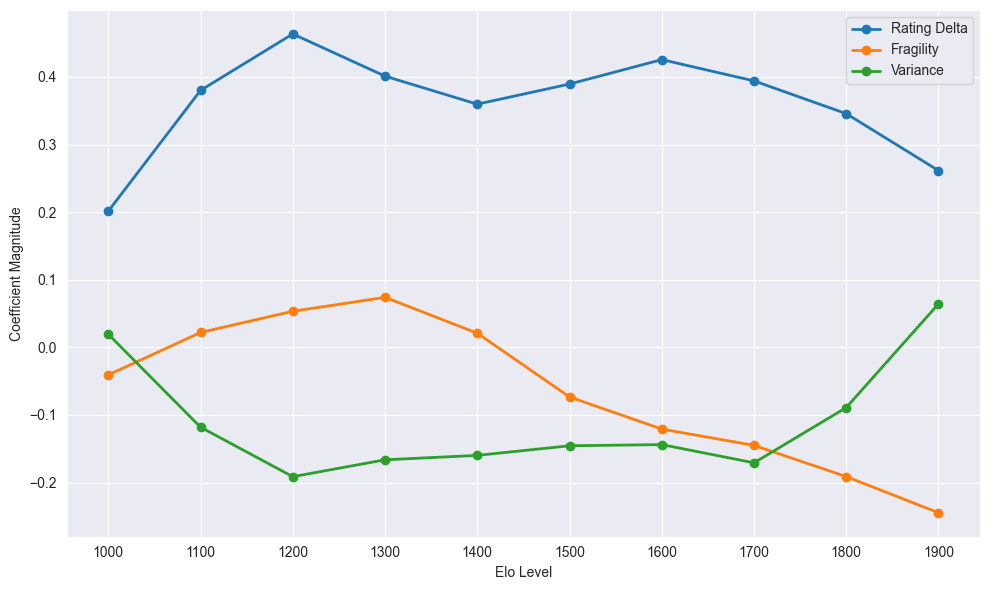

Importances Top-1:
                  elo_1000  elo_1100  elo_1200  elo_1300  elo_1400  elo_1500  \
delta            0.305362  0.350838  0.354250  0.285470  0.358230  0.382289   
fragility_score  0.350504  0.295630  0.359087  0.322444  0.331877  0.334052   
variance         0.344135  0.353532  0.286663  0.392086  0.309893  0.283660   

                 elo_1600  elo_1700  elo_1800  elo_1900  
delta            0.281855  0.381419  0.295741  0.343297  
fragility_score  0.344504  0.316510  0.327698  0.340404  
variance         0.373641  0.302071  0.376561  0.316299   

Importances Top-2:
                  elo_1000  elo_1100  elo_1200  elo_1300  elo_1400  elo_1500  \
delta            0.419222  0.387654  0.406821  0.396253  0.323479  0.335437   
fragility_score  0.272538  0.315188  0.305343  0.312540  0.290531  0.263097   
variance         0.308240  0.297158  0.287836  0.291207  0.385991  0.401466   

                 elo_1600  elo_1700  elo_1800  elo_1900  
delta            0.365783  0.42157

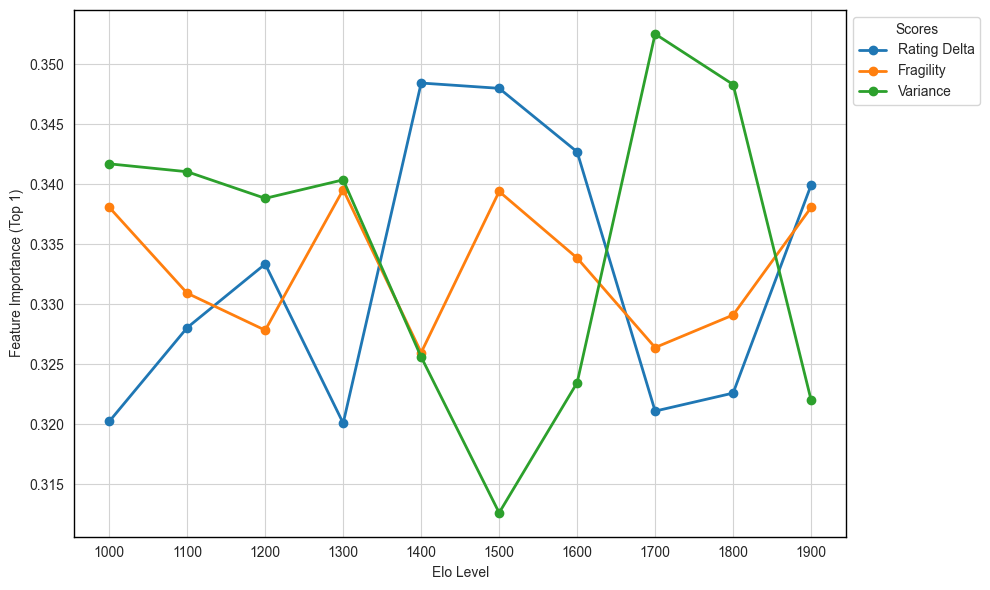

✅ Saved enriched dataset to 'data/recommendation_dataset.parquet'


In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.signal import savgol_filter
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

sns.set_style("darkgrid")

# ─── 1. Konstanten definieren ───────────────────────────────────────────────────
FEATURES = ['delta', 'fragility_score', 'variance']
ELOS = list(range(1000, 2000, 100))

# ─── 2. Dataset laden ────────────────────────────────────────────────────────────
df = pd.read_parquet("../data/stats_dataset.parquet")

# ─── 3. Zuerst: LogReg-Koeffizienten für Top-1 berechnen ───────────────────────────
coefficients = pd.DataFrame(index=FEATURES)
for elo in ELOS:
    target = f'is_historical_best_{elo}'
    if target in df.columns:
        subset = df.dropna(subset=FEATURES + [target])
        if subset[target].nunique() > 1:
            X = subset[FEATURES]
            y = subset[target].astype(int)
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, stratify=y, random_state=1, test_size=0.25
            )
            model = LogisticRegression()
            model.fit(X_train, y_train)
            coefficients[f'elo_{elo}'] = model.coef_[0]
        else:
            coefficients[f'elo_{elo}'] = [float('nan')] * len(FEATURES)
    else:
        coefficients[f'elo_{elo}'] = [float('nan')] * len(FEATURES)

# (Optional) Plot der koeffizienten
feature_labels = {
    "fragility_score": "Fragility",
    "delta": "Rating Delta",
    "variance": "Variance"
}

plt.figure(figsize=(10, 6))
for feature in FEATURES:
    y = coefficients.loc[feature, coefficients.columns].values
    y_smooth = savgol_filter(y, window_length=5, polyorder=2)
    plt.plot(ELOS, y_smooth, marker='o', linewidth=2, label=feature_labels[feature])
plt.xlabel("Elo Level")
plt.ylabel("Coefficient Magnitude")
plt.xticks(ELOS)
plt.legend()
plt.tight_layout()
plt.savefig("../images/feature_coefficients.pdf")
plt.show()

# ─── 4. Feature Importances berechnen (Top-1, Top-2, Top-3) ───────────────────────
importances_best = pd.DataFrame(index=FEATURES)
importances_top2 = pd.DataFrame(index=FEATURES)
importances_top3 = pd.DataFrame(index=FEATURES)

for elo in ELOS:
    tgt_best = f"is_historical_best_{elo}"
    tgt_top2 = f"is_historical_top2_{elo}"
    tgt_top3 = f"is_historical_top3_{elo}"

    # Top-1
    if tgt_best in df.columns:
        subset_b = df.dropna(subset=FEATURES + [tgt_best])
        if subset_b[tgt_best].nunique() > 1:
            Xb = subset_b[FEATURES]
            yb = subset_b[tgt_best].astype(int)
            Xb_train, Xb_test, yb_train, yb_test = train_test_split(
                Xb, yb, stratify=yb, random_state=1, test_size=0.25
            )
            model_b = XGBClassifier(eval_metric='logloss')
            model_b.fit(Xb_train, yb_train)
            importances_best[f'elo_{elo}'] = model_b.feature_importances_
        else:
            importances_best[f'elo_{elo}'] = [float('nan')] * len(FEATURES)
    else:
        importances_best[f'elo_{elo}'] = [float('nan')] * len(FEATURES)

    # Top-2
    if tgt_top2 in df.columns:
        subset_2 = df.dropna(subset=FEATURES + [tgt_top2])
        if subset_2[tgt_top2].nunique() > 1:
            X2 = subset_2[FEATURES]
            y2 = subset_2[tgt_top2].astype(int)
            X2_train, X2_test, y2_train, y2_test = train_test_split(
                X2, y2, stratify=y2, random_state=1, test_size=0.25
            )
            model_2 = XGBClassifier(eval_metric='logloss')
            model_2.fit(X2_train, y2_train)
            importances_top2[f'elo_{elo}'] = model_2.feature_importances_
        else:
            importances_top2[f'elo_{elo}'] = [float('nan')] * len(FEATURES)
    else:
        importances_top2[f'elo_{elo}'] = [float('nan')] * len(FEATURES)

    # Top-3
    if tgt_top3 in df.columns:
        subset_3 = df.dropna(subset=FEATURES + [tgt_top3])
        if subset_3[tgt_top3].nunique() > 1:
            X3 = subset_3[FEATURES]
            y3 = subset_3[tgt_top3].astype(int)
            X3_train, X3_test, y3_train, y3_test = train_test_split(
                X3, y3, stratify=y3, random_state=1, test_size=0.25
            )
            model_3 = XGBClassifier(eval_metric='logloss')
            model_3.fit(X3_train, y3_train)
            importances_top3[f'elo_{elo}'] = model_3.feature_importances_
        else:
            importances_top3[f'elo_{elo}'] = [float('nan')] * len(FEATURES)
    else:
        importances_top3[f'elo_{elo}'] = [float('nan')] * len(FEATURES)

# (Optional) Ausgabe zum Prüfen
print("Importances Top-1:\n", importances_best.head(), "\n")
print("Importances Top-2:\n", importances_top2.head(), "\n")
print("Importances Top-3:\n", importances_top3.head(), "\n")

# ─── 5. Plot der geglätteten Feature Importances (nur Top-1) ─────────────────────
fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.set_facecolor("white")

for feature in FEATURES:
    y = importances_best.loc[feature, importances_best.columns].values
    y_smooth = savgol_filter(y, window_length=5, polyorder=2)
    ax.plot(ELOS, y_smooth, marker='o', linewidth=2, label=feature_labels[feature])

ax.set_axisbelow(True)
ax.grid(True, color="lightgray")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)

ax.set_xlabel("Elo Level")
ax.set_ylabel("Feature Importance (Top 1)")
ax.set_xticks(ELOS)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Scores",
    facecolor="white"
)

fig.tight_layout()
fig.savefig("../images/feature_importance_top1.pdf")
plt.show()

# ─── 6. Move-Empfehlung berechnen (Top-1, Top-2, Top-3) ─────────────────────────────
for elo in ELOS:
    score_col    = f"score_{elo}"
    rec_col      = f"recommended_move_{elo}"
    is_best_col  = f"is_best_{elo}"
    is_top2_col  = f"is_top2_{elo}"
    is_top3_col  = f"is_top3_{elo}"
    is_engine_col= f"is_engine_best_{elo}"
    elo_col      = f"elo_{elo}"
    group_count_col = f"group_count_{elo}"
    hist_best_col  = f"historical_best_{elo}"
    hist_top2_col  = f"historical_top2_{elo}"
    hist_top3_col  = f"historical_top3_{elo}"

    # Score aus LogReg-Koeffizienten
    df[score_col] = (
        coefficients.loc["delta", elo_col] * df["delta"] +
        coefficients.loc["fragility_score", elo_col] * df["fragility_score"] +
        coefficients.loc["variance", elo_col] * df["variance"]
    )

    # Empfehlung: Move mit höchstem Score
    idx_best_score = df.groupby("fen")[score_col].idxmax().dropna().astype(int)
    recommended = df.loc[idx_best_score, ["fen", "next_move"]].set_index("fen")["next_move"]
    df[rec_col] = df["fen"].map(recommended)

    # Top-1-Flag
    df[is_best_col] = df.apply(
        lambda r: r[rec_col] in r[hist_best_col],
        axis=1
    ).astype("boolean")

    # Top-2-Flag (falls Liste existiert)
    if hist_top2_col in df.columns:
        df[is_top2_col] = df.apply(
            lambda r: r[rec_col] in r[hist_top2_col],
            axis=1
        ).astype("boolean")
    else:
        df[is_top2_col] = pd.NA

    # Top-3-Flag (falls Liste existiert)
    if hist_top3_col in df.columns:
        df[is_top3_col] = df.apply(
            lambda r: r[rec_col] in r[hist_top3_col],
            axis=1
        ).astype("boolean")
    else:
        df[is_top3_col] = pd.NA

    # Engine-Flag
    df[is_engine_col] = df.apply(
        lambda r: r["engine_move"] in r[hist_best_col],
        axis=1
    ).astype("boolean")

    # Maskiere Positionen mit <20 Samples
    invalid_mask = (
        (df[group_count_col] < 20) |
        (df[group_count_col].isna())
    )
    df.loc[invalid_mask, [is_best_col, is_top2_col, is_top3_col, is_engine_col]] = pd.NA

    # Ungültige Engine-Moves entfernen
    valid_moves_per_fen = df.groupby("fen")["next_move"].agg(set).to_dict()
    df["engine_valid_move"] = df.apply(
        lambda row: row["engine_move"] in valid_moves_per_fen.get(row["fen"], set()),
        axis=1
    )
    df.loc[~df["engine_valid_move"], [is_engine_col]] = pd.NA
    df.drop(columns="engine_valid_move", inplace=True)

# ─── 7. Ergebnis abspeichern ────────────────────────────────────────────────────
df.to_parquet("../data/recommendation_dataset.parquet", index=False)
print("✅ Saved enriched dataset to 'data/recommendation_dataset.parquet'")
